Enter your RNA sequence (A,U,G,C or A,T,G,C): AUCCGUUUGACGUCUGACUACAACCGAUGGUACAUGCAA
Sequence (wrapped):
   AUCCGUUUGACGUCUGACUACAACCGAUGGUACAUGCAA
Dot-bracket structure (with pseudoknots):
   [((((](((([(([[])))])))).)((]([.)))).)]
Base pairs:
   [(1, 37), (2, 35), (26, 34), (27, 33), (29, 32), (3, 25), (4, 23), (6, 22), (7, 21), (8, 20), (9, 18), (11, 17), (12, 16)]
Pseudoknot pairs:
   [(0, 5), (10, 15), (13, 28), (14, 19), (30, 38)]
Total Free Energy (approx) without pseudoknots: -32.0 kcal/mol
Pseudoknot Energy contribution (approx): -12.0 kcal/mol
Total Free Energy including Pseudoknots (approx): -44.0 kcal/mol


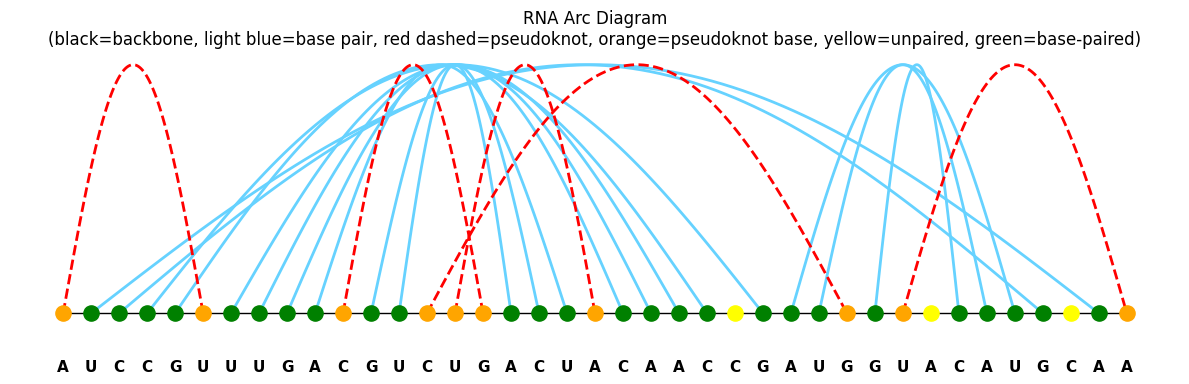

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import sys

sys.setrecursionlimit(3000)

BASE_PAIR_ENERGY = {
    ('A', 'U'): -2.0,
    ('U', 'A'): -2.0,
    ('C', 'G'): -3.0,
    ('G', 'C'): -3.0,
    ('G', 'U'): -1.0,
    ('U', 'G'): -1.0,
}
ACCEPTED_BASES = {'A', 'U', 'G', 'C', 'T'}
VALID_BASES = {'A', 'U', 'G', 'C'}
MIN_LOOP_LENGTH = 3

def can_pair(b1, b2):
    return (b1, b2) in BASE_PAIR_ENERGY

class SparseDPMatrix:
    def __init__(self):
        self.data = defaultdict(dict)
    def set(self, i, j, value):
        self.data[i][j] = value
    def get(self, i, j):
        if i > j:
            return 0
        return self.data.get(i, {}).get(j, float('inf'))

def stack_backtrack(traceback, n):
    structure = ['.'] * n
    pairs = []
    stack = [(0, n - 1)]
    while stack:
        i, j = stack.pop()
        if i >= j:
            continue
        tb = traceback.get((i, j))
        if tb is None:
            continue
        if len(tb) == 2:
            stack.append((tb[0], tb[1]))
        elif len(tb) == 3 and tb[2]:
            structure[i] = '('
            structure[j] = ')'
            pairs.append((i, j))
            stack.append((tb[0], tb[1]))
        elif len(tb) == 4:
            stack.append((tb[0], tb[1]))
            stack.append((tb[2], tb[3]))
    return ''.join(structure), pairs

def predict_structure(sequence):
    n = len(sequence)
    dp = SparseDPMatrix()
    traceback = {}

    for i in range(n):
        dp.set(i, i, 0)
        if i < n - 1:
            dp.set(i, i + 1, 0)

    for l in range(2, n):
        for i in range(n - l):
            j = i + l
            if j - i < MIN_LOOP_LENGTH:
                dp.set(i, j, 0)
                continue

            min_energy = dp.get(i + 1, j)
            tb = (i + 1, j)

            if dp.get(i, j - 1) < min_energy:
                min_energy = dp.get(i, j - 1)
                tb = (i, j - 1)

            if can_pair(sequence[i], sequence[j]):
                pair_energy = BASE_PAIR_ENERGY[(sequence[i], sequence[j])]
                val = dp.get(i + 1, j - 1) + pair_energy
                if val < min_energy:
                    min_energy = val
                    tb = (i + 1, j - 1, True)

            for k in range(i + 1, j):
                val = dp.get(i, k) + dp.get(k + 1, j)
                if val < min_energy:
                    min_energy = val
                    tb = (i, k, k + 1, j)

            dp.set(i, j, min_energy)
            traceback[(i, j)] = tb

    structure, pairs = stack_backtrack(traceback, n)
    total_energy = dp.get(0, n - 1)
    return structure, pairs, total_energy

def detect_pseudoknots(sequence, base_pairs, min_loop_length=3):
    n = len(sequence)
    paired = [False] * n
    for i, j in base_pairs:
        paired[i] = True
        paired[j] = True

    pseudoknot_pairs = []
    while True:
        found = False
        unpaired_indices = [idx for idx in range(n) if not paired[idx]]
        for i in unpaired_indices:
            for j in range(i + min_loop_length + 1, n):
                if not paired[j] and can_pair(sequence[i], sequence[j]):
                    pseudoknot_pairs.append((i, j))
                    paired[i] = True
                    paired[j] = True
                    found = True
                    break
            if found:
                break
        if not found:
            break
    return pseudoknot_pairs, paired

def arc_diagram(sequence, base_pairs, pseudoknot_pairs, paired_status):
    n = len(sequence)
    x = np.arange(n)
    y = np.zeros(n)
    plt.figure(figsize=(max(n/5, 12), 4))

    pseudoknot_indices = {i for pair in pseudoknot_pairs for i in pair}
    base_pair_indices = {i for pair in base_pairs for i in pair}

    plt.plot(x, y, color="black", linewidth=1, zorder=1)
    for i, base in enumerate(sequence):
        if i in pseudoknot_indices:
            color = 'orange'
        elif paired_status[i]:
            color = 'green'
        else:
            color = 'yellow'
        plt.scatter(i, 0, s=120, color=color, zorder=3)
        plt.text(i, -0.15, base, ha='center', va='center', fontsize=11, fontweight='bold')

    for i, j in base_pairs:
        if i > j: i, j = j, i
        arc = np.linspace(0, np.pi, 100)
        plt.plot(np.linspace(i, j, 100), 0.7*np.sin(arc), color="#66d2ff", linewidth=2, zorder=2)

    for i, j in pseudoknot_pairs:
        if i > j: i, j = j, i
        arc = np.linspace(0, np.pi, 100)
        plt.plot(np.linspace(i, j, 100), 0.7*np.sin(arc), color="red", linewidth=2, linestyle='dashed', zorder=2)

    plt.axis('off')
    plt.title("RNA Arc Diagram\n(black=backbone, light blue=base pair, red dashed=pseudoknot, orange=pseudoknot base, yellow=unpaired, green=base-paired)")
    plt.tight_layout()
    plt.show()

def pseudoknot_dot_bracket(structure, pseudoknot_pairs):
    structure_list = list(structure)
    for i, j in pseudoknot_pairs:
        if structure_list[i] == '.' and structure_list[j] == '.':
            structure_list[i] = '['
            structure_list[j] = ']'
    return "".join(structure_list)

def print_block(title, items, max_per_line=15):
    if title:
        print(f"{title}:")
    if isinstance(items, str):
        for i in range(0, len(items), max_per_line):
            print("  ", items[i:i+max_per_line])
    else:
        for i in range(0, len(items), max_per_line):
            print("  ", items[i:i+max_per_line])


if __name__ == "__main__":
    sequence = ''.join(input("Enter your RNA sequence (A,U,G,C or A,T,G,C): ").upper().split())
    if 'U' in sequence and 'T' in sequence:
        print("Invalid input! Sequence cannot contain both 'U' and 'T'. Please use only one (AUGC or ATGC).")
        sys.exit(1)
    sequence = sequence.replace('T', 'U')
    if any(base not in VALID_BASES for base in sequence):
        print("Invalid sequence! Only A, U, G, C (or T as U) are allowed.")
        sys.exit(1)

    structure, pairs, energy = predict_structure(sequence)
    pseudoknot_pairs, paired_status = detect_pseudoknots(sequence, pairs)

    pseudoknot_energy = sum(BASE_PAIR_ENERGY.get((sequence[i], sequence[j]), 0) for i, j in pseudoknot_pairs)
    total_energy_with_pseudoknots = energy + pseudoknot_energy
    structure_with_pk = pseudoknot_dot_bracket(structure, pseudoknot_pairs)

    print("Sequence (wrapped):")
    print_block("", sequence, 100)
    print_block("Dot-bracket structure (with pseudoknots)", structure_with_pk, 100)
    print_block("Base pairs", pairs, 15)
    print_block("Pseudoknot pairs", pseudoknot_pairs, 15)
    print("Total Free Energy (approx) without pseudoknots:", energy, "kcal/mol")
    print("Pseudoknot Energy contribution (approx):", pseudoknot_energy, "kcal/mol")
    print("Total Free Energy including Pseudoknots (approx):", total_energy_with_pseudoknots, "kcal/mol")
    arc_diagram(sequence, pairs, pseudoknot_pairs, paired_status)
